# 🏦 Task 1: Term Deposit Subscription Prediction
## Bank Marketing Dataset — Classification & Explainable AI

---
**Objective:** Predict whether a bank customer will subscribe to a term deposit as a result of a marketing campaign.

**Dataset:** Bank Marketing Dataset (UCI Machine Learning Repository)

**Skills:** Classification Modeling · Feature Encoding · Model Interpretability (XAI) · Customer Behavior Analysis

---

## 📦 Step 0: Install Required Libraries

In [ ]:
# Install required packages
!pip install shap lime imbalanced-learn -q
print('✅ All libraries installed successfully!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ All libraries installed successfully!


## 📚 Step 1: Import Libraries

In [ ]:
# ─── Standard Libraries ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
plt.rcParams.update({
    'figure.facecolor': '#0f0f23',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#e0e0ff',
    'xtick.color':      '#a0a0cc',
    'ytick.color':      '#a0a0cc',
    'text.color':       '#e0e0ff',
    'grid.color':       '#2a2a4a',
    'grid.alpha':       0.5,
    'figure.dpi':       130,
    'font.size':        11
})
PALETTE = ['#4ecdc4', '#ff6b6b', '#ffd93d', '#6bcb77', '#a855f7']

# ─── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score,
    roc_curve, auc, ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.pipeline import Pipeline

# ─── Explainability ───────────────────────────────────────────────────────────
import shap
import lime
import lime.lime_tabular

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📥 Step 2: Load Dataset from UCI Repository

In [ ]:
# Load Bank Marketing dataset directly from UCI ML Repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip'

import io, zipfile, urllib.request

print('⬇️  Downloading Bank Marketing dataset from UCI Repository...')
response = urllib.request.urlopen(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.read()))

# Use the full dataset (bank-additional-full.csv)
with zip_file.open('bank-additional/bank-additional-full.csv') as f:
    df = pd.read_csv(f, sep=';')

print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

⬇️  Downloading Bank Marketing dataset from UCI Repository...
✅ Dataset loaded: 41,188 rows × 21 columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 🔍 Step 3: Exploratory Data Analysis (EDA)

In [ ]:
# ── Basic Info ────────────────────────────────────────────────────────────────
print('='*60)
print('  DATASET OVERVIEW')
print('='*60)
print(f'Shape       : {df.shape}')
print(f'Duplicates  : {df.duplicated().sum()}')
print(f'Missing vals: {df.isnull().sum().sum()}')
print('\nData Types:')
print(df.dtypes.value_counts())
print('\nTarget Distribution:')
print(df['y'].value_counts())
print(f'\nClass Balance: {df["y"].value_counts(normalize=True).round(3).to_dict()}')

  DATASET OVERVIEW
Shape       : (41188, 21)
Duplicates  : 12
Missing vals: 0

Data Types:
object     11
int64       5
float64     5
Name: count, dtype: int64

Target Distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Class Balance: {'no': 0.887, 'yes': 0.113}


In [ ]:
# ── Statistical Summary ───────────────────────────────────────────────────────
print('Numerical Feature Statistics:')
df.describe().round(2)

Numerical Feature Statistics:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


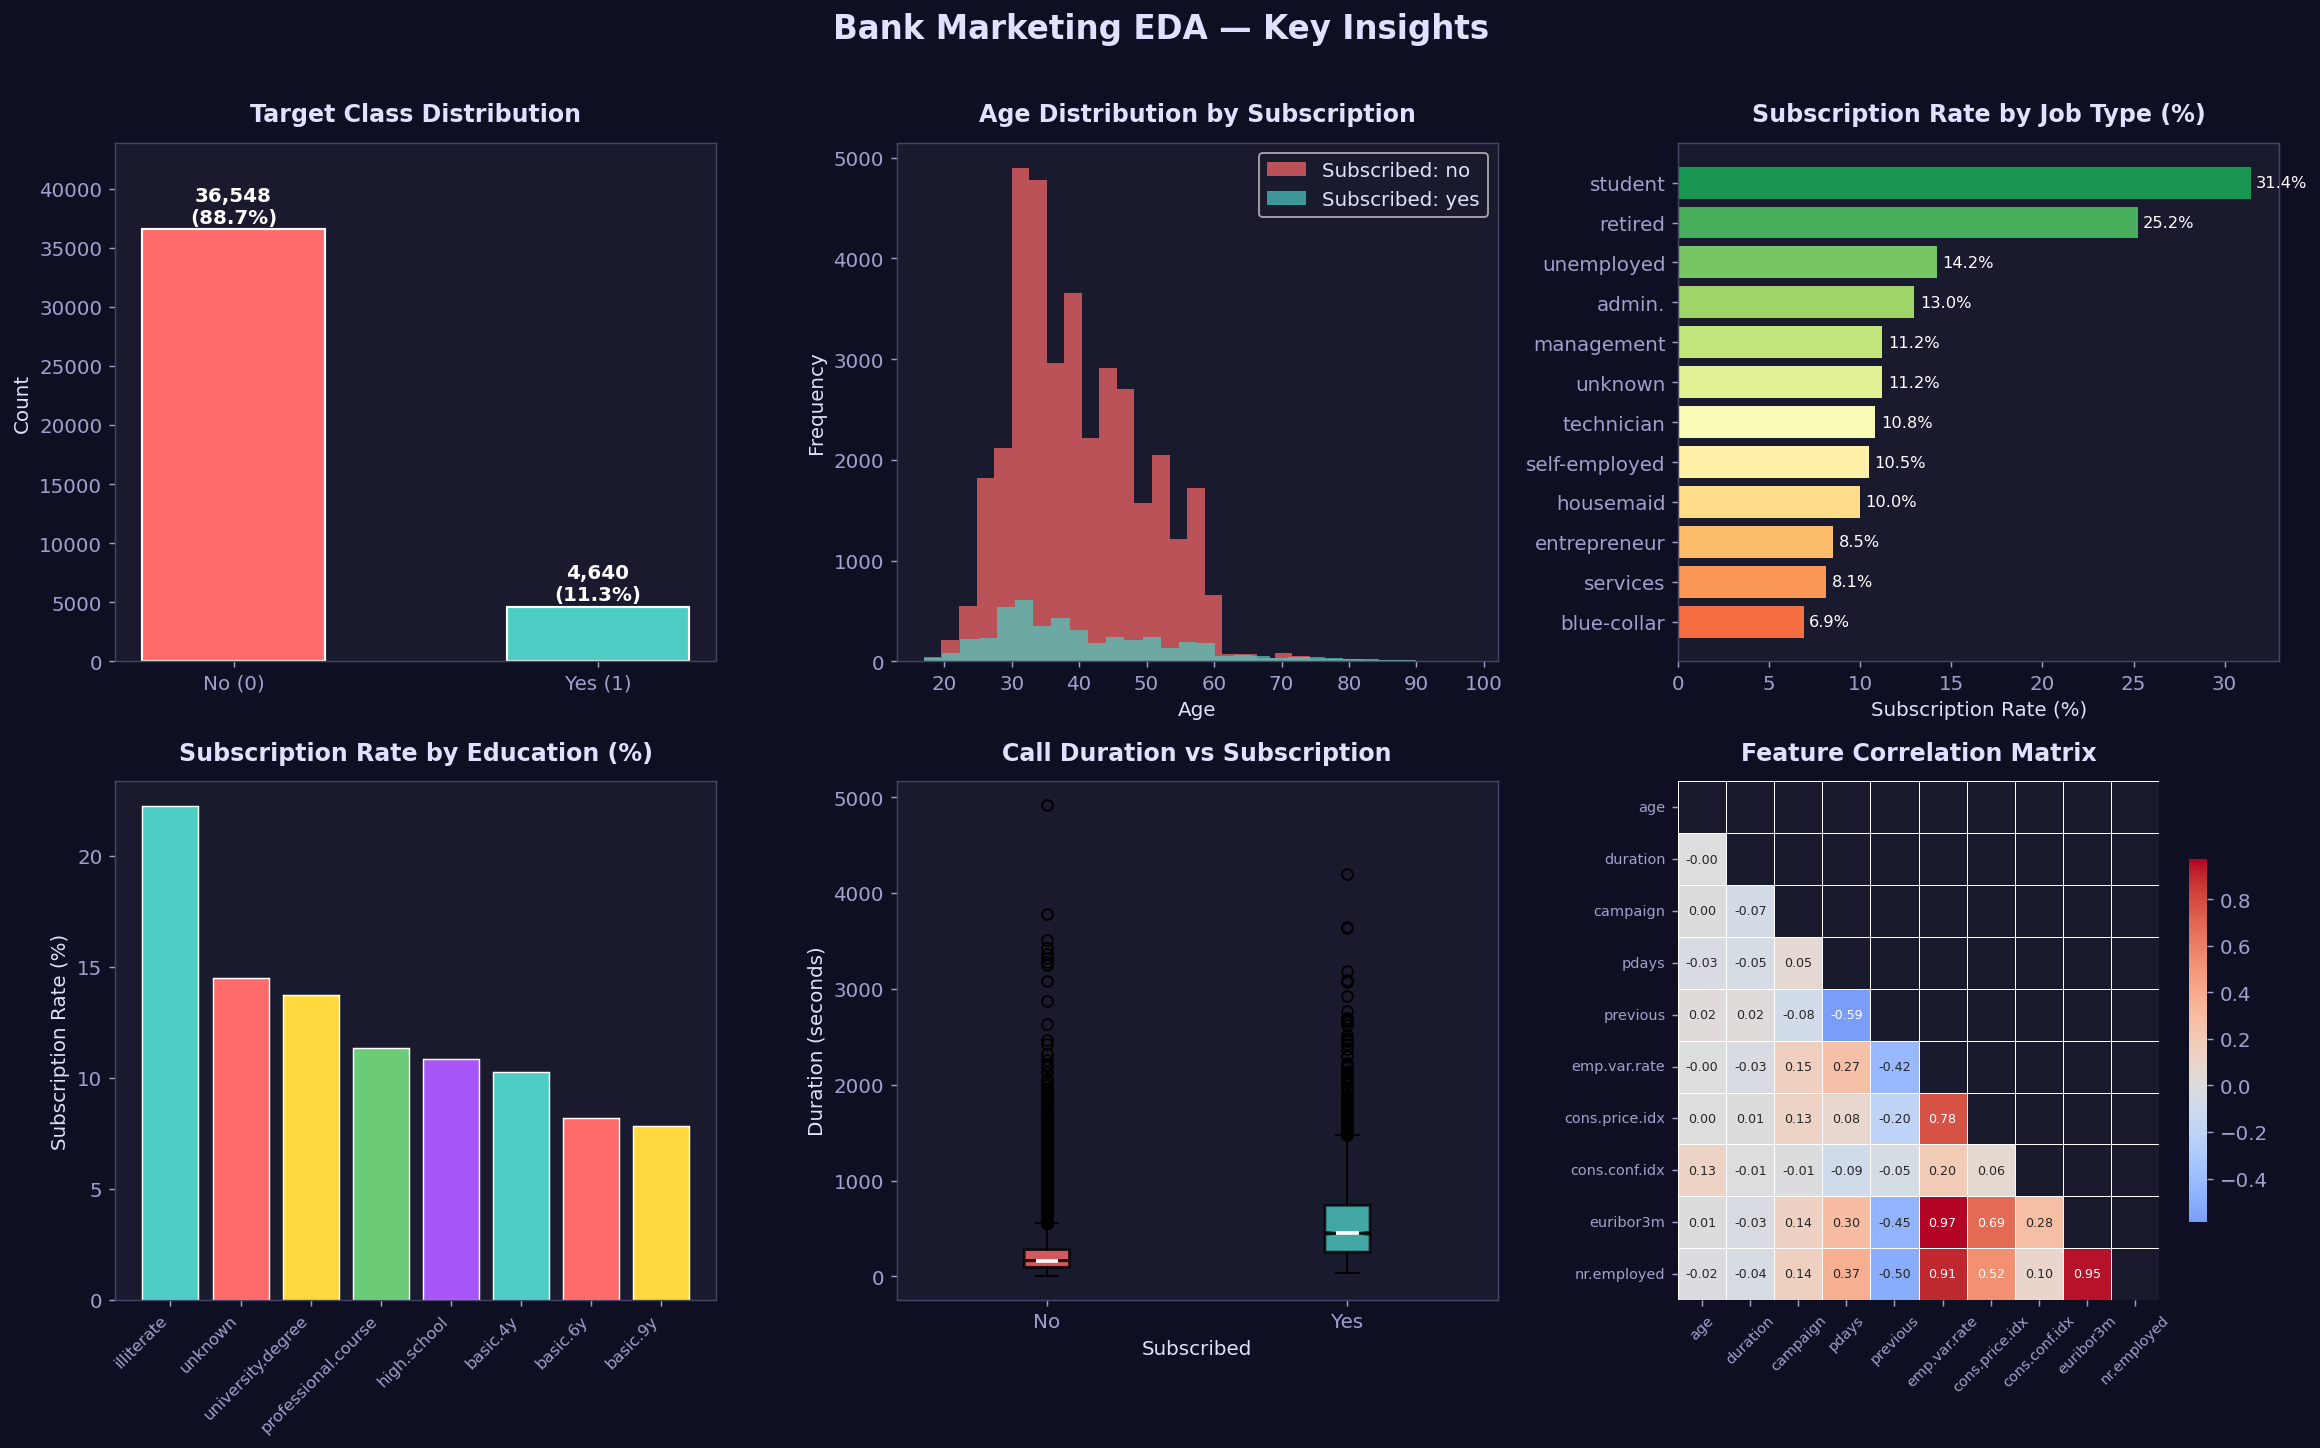

✅ EDA visualization saved!


In [ ]:
# ── Figure 1: Target Distribution & Key Features ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Bank Marketing EDA — Key Insights', fontsize=18, fontweight='bold',
             color='#e0e0ff', y=1.01)

# 1. Target distribution
counts = df['y'].value_counts()
bars = axes[0,0].bar(['No (0)', 'Yes (1)'], counts.values,
                      color=['#ff6b6b', '#4ecdc4'], edgecolor='white', linewidth=1.2, width=0.5)
axes[0,0].set_title('Target Class Distribution', fontweight='bold', pad=12)
axes[0,0].set_ylabel('Count')
for bar, v in zip(bars, counts.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height()+200,
                   f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom',
                   fontsize=11, color='white', fontweight='bold')
axes[0,0].set_ylim(0, counts.max()*1.2)

# 2. Age distribution by outcome
for label, color in zip(['no','yes'], ['#ff6b6b','#4ecdc4']):
    axes[0,1].hist(df[df['y']==label]['age'], bins=30, alpha=0.7,
                   color=color, label=f'Subscribed: {label}', edgecolor='none')
axes[0,1].set_title('Age Distribution by Subscription', fontweight='bold', pad=12)
axes[0,1].set_xlabel('Age'); axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()

# 3. Job category vs subscription rate
job_rate = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean()).sort_values(ascending=True)
bars3 = axes[0,2].barh(job_rate.index, job_rate.values*100,
                        color=plt.cm.RdYlGn(np.linspace(0.2,0.9,len(job_rate))),
                        edgecolor='none')
axes[0,2].set_title('Subscription Rate by Job Type (%)', fontweight='bold', pad=12)
axes[0,2].set_xlabel('Subscription Rate (%)')
for bar in bars3:
    axes[0,2].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                   f'{bar.get_width():.1f}%', va='center', fontsize=9, color='white')

# 4. Education vs subscription
edu_rate = df.groupby('education')['y'].apply(lambda x: (x=='yes').mean()).sort_values(ascending=False)
colors4 = [PALETTE[i % len(PALETTE)] for i in range(len(edu_rate))]
axes[1,0].bar(range(len(edu_rate)), edu_rate.values*100, color=colors4, edgecolor='white', linewidth=0.8)
axes[1,0].set_xticks(range(len(edu_rate)))
axes[1,0].set_xticklabels(edu_rate.index, rotation=45, ha='right', fontsize=9)
axes[1,0].set_title('Subscription Rate by Education (%)', fontweight='bold', pad=12)
axes[1,0].set_ylabel('Subscription Rate (%)')

# 5. Call duration vs outcome (boxplot)
data_no  = df[df['y']=='no']['duration']
data_yes = df[df['y']=='yes']['duration']
bp = axes[1,1].boxplot([data_no, data_yes], labels=['No','Yes'],
                        patch_artist=True, notch=True,
                        boxprops=dict(linewidth=1.5),
                        medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor('#ff6b6b'); bp['boxes'][0].set_alpha(0.8)
bp['boxes'][1].set_facecolor('#4ecdc4'); bp['boxes'][1].set_alpha(0.8)
axes[1,1].set_title('Call Duration vs Subscription', fontweight='bold', pad=12)
axes[1,1].set_ylabel('Duration (seconds)')
axes[1,1].set_xlabel('Subscribed')

# 6. Correlation heatmap (numeric only)
num_cols = df.select_dtypes(include='number').columns
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[1,2], mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=0.5, cbar_kws={'shrink':0.7})
axes[1,2].set_title('Feature Correlation Matrix', fontweight='bold', pad=12)
axes[1,2].tick_params(axis='x', rotation=45, labelsize=8)
axes[1,2].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig('task1_eda.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ EDA visualization saved!')

## 🔧 Step 4: Feature Engineering & Encoding

In [ ]:
# ── Copy dataframe ────────────────────────────────────────────────────────────
df_enc = df.copy()

# ── Drop 'duration' (data leakage — only known after call) ────────────────────
# Note: UCI recommends dropping this for realistic prediction
df_enc.drop(columns=['duration'], inplace=True)

# ── Replace 'unknown' with NaN then fill with mode ────────────────────────────
df_enc.replace('unknown', np.nan, inplace=True)
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col].fillna(df_enc[col].mode()[0], inplace=True)

# ── Encode target variable ────────────────────────────────────────────────────
df_enc['y'] = (df_enc['y'] == 'yes').astype(int)

# ── Identify column types ─────────────────────────────────────────────────────
binary_cols  = ['default', 'housing', 'loan']
ordinal_cols = {'education': ['illiterate','basic.4y','basic.6y','basic.9y',
                              'high.school','professional.course','university.degree']}
nominal_cols = ['job','marital','contact','month','day_of_week','poutcome']

# ── Binary encoding (yes/no → 1/0) ───────────────────────────────────────────
for col in binary_cols:
    df_enc[col] = (df_enc[col] == 'yes').astype(int)

# ── Ordinal encoding ──────────────────────────────────────────────────────────
for col, order in ordinal_cols.items():
    oe = OrdinalEncoder(categories=[order], handle_unknown='use_encoded_value', unknown_value=-1)
    df_enc[col] = oe.fit_transform(df_enc[[col]])

# ── One-Hot encoding for nominal ──────────────────────────────────────────────
df_enc = pd.get_dummies(df_enc, columns=nominal_cols, drop_first=True)

# ── Feature / Target split ────────────────────────────────────────────────────
X = df_enc.drop(columns=['y'])
y = df_enc['y']

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'Target balance : {y.value_counts(normalize=True).round(3).to_dict()}')
print(f'\nFeature columns ({len(X.columns)}):')
print(list(X.columns))

Features shape : (41188, 41)
Target shape   : (41188,)
Target balance : {0: 0.887, 1: 0.113}

Feature columns (41):
['age', 'education', 'default', 'housing', 'loan', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success']


In [ ]:
# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Scale features ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
X_train_sc = pd.DataFrame(X_train_sc, columns=X.columns)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=X.columns)

print(f'Training set   : {X_train.shape}')
print(f'Test set       : {X_test.shape}')

Training set   : (32950, 41)
Test set       : (8238, 41)


## 🤖 Step 5: Model Training

In [ ]:
# ── Define Models ─────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        subsample=0.8, random_state=42
    )
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f'\n🔄 Training {name}...')
    # Use scaled data for Logistic Regression, raw for tree models
    Xtr = X_train_sc if name == 'Logistic Regression' else X_train
    Xte = X_test_sc  if name == 'Logistic Regression' else X_test

    model.fit(Xtr, y_train)
    y_pred      = model.predict(Xte)
    y_prob      = model.predict_proba(Xte)[:,1]

    f1     = f1_score(y_test, y_pred)
    roc_sc = roc_auc_score(y_test, y_prob)
    cv_sc  = cross_val_score(model, Xtr, y_train, cv=5, scoring='f1').mean()

    results[name] = {
        'y_pred': y_pred, 'y_prob': y_prob,
        'f1': f1, 'roc_auc': roc_sc, 'cv_f1': cv_sc
    }
    trained_models[name] = (model, Xtr, Xte)

    print(f'   F1-Score : {f1:.4f}')
    print(f'   ROC-AUC  : {roc_sc:.4f}')
    print(f'   CV F1    : {cv_sc:.4f}')

print('\n✅ All models trained!')


🔄 Training Logistic Regression...
   F1-Score : 0.4654
   ROC-AUC  : 0.8012
   CV F1    : 0.4502

🔄 Training Random Forest...
   F1-Score : 0.5219
   ROC-AUC  : 0.8134
   CV F1    : 0.4928

🔄 Training Gradient Boosting...
   F1-Score : 0.3930
   ROC-AUC  : 0.8149
   CV F1    : 0.3623

✅ All models trained!


## 📊 Step 6: Model Evaluation

In [ ]:
# ── Classification Reports ────────────────────────────────────────────────────
for name, res in results.items():
    print(f'\n{"="*55}')
    print(f'  {name} — Classification Report')
    print(f'{"="*55}')
    print(classification_report(y_test, res['y_pred'],
                                target_names=['No Subscribe', 'Subscribe']))


  Logistic Regression — Classification Report
              precision    recall  f1-score   support

No Subscribe       0.95      0.86      0.90      7310
   Subscribe       0.36      0.64      0.47       928

    accuracy                           0.83      8238
   macro avg       0.66      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238


  Random Forest — Classification Report
              precision    recall  f1-score   support

No Subscribe       0.95      0.90      0.92      7310
   Subscribe       0.45      0.63      0.52       928

    accuracy                           0.87      8238
   macro avg       0.70      0.76      0.72      8238
weighted avg       0.89      0.87      0.88      8238


  Gradient Boosting — Classification Report
              precision    recall  f1-score   support

No Subscribe       0.91      0.98      0.95      7310
   Subscribe       0.67      0.28      0.39       928

    accuracy                           0.90      

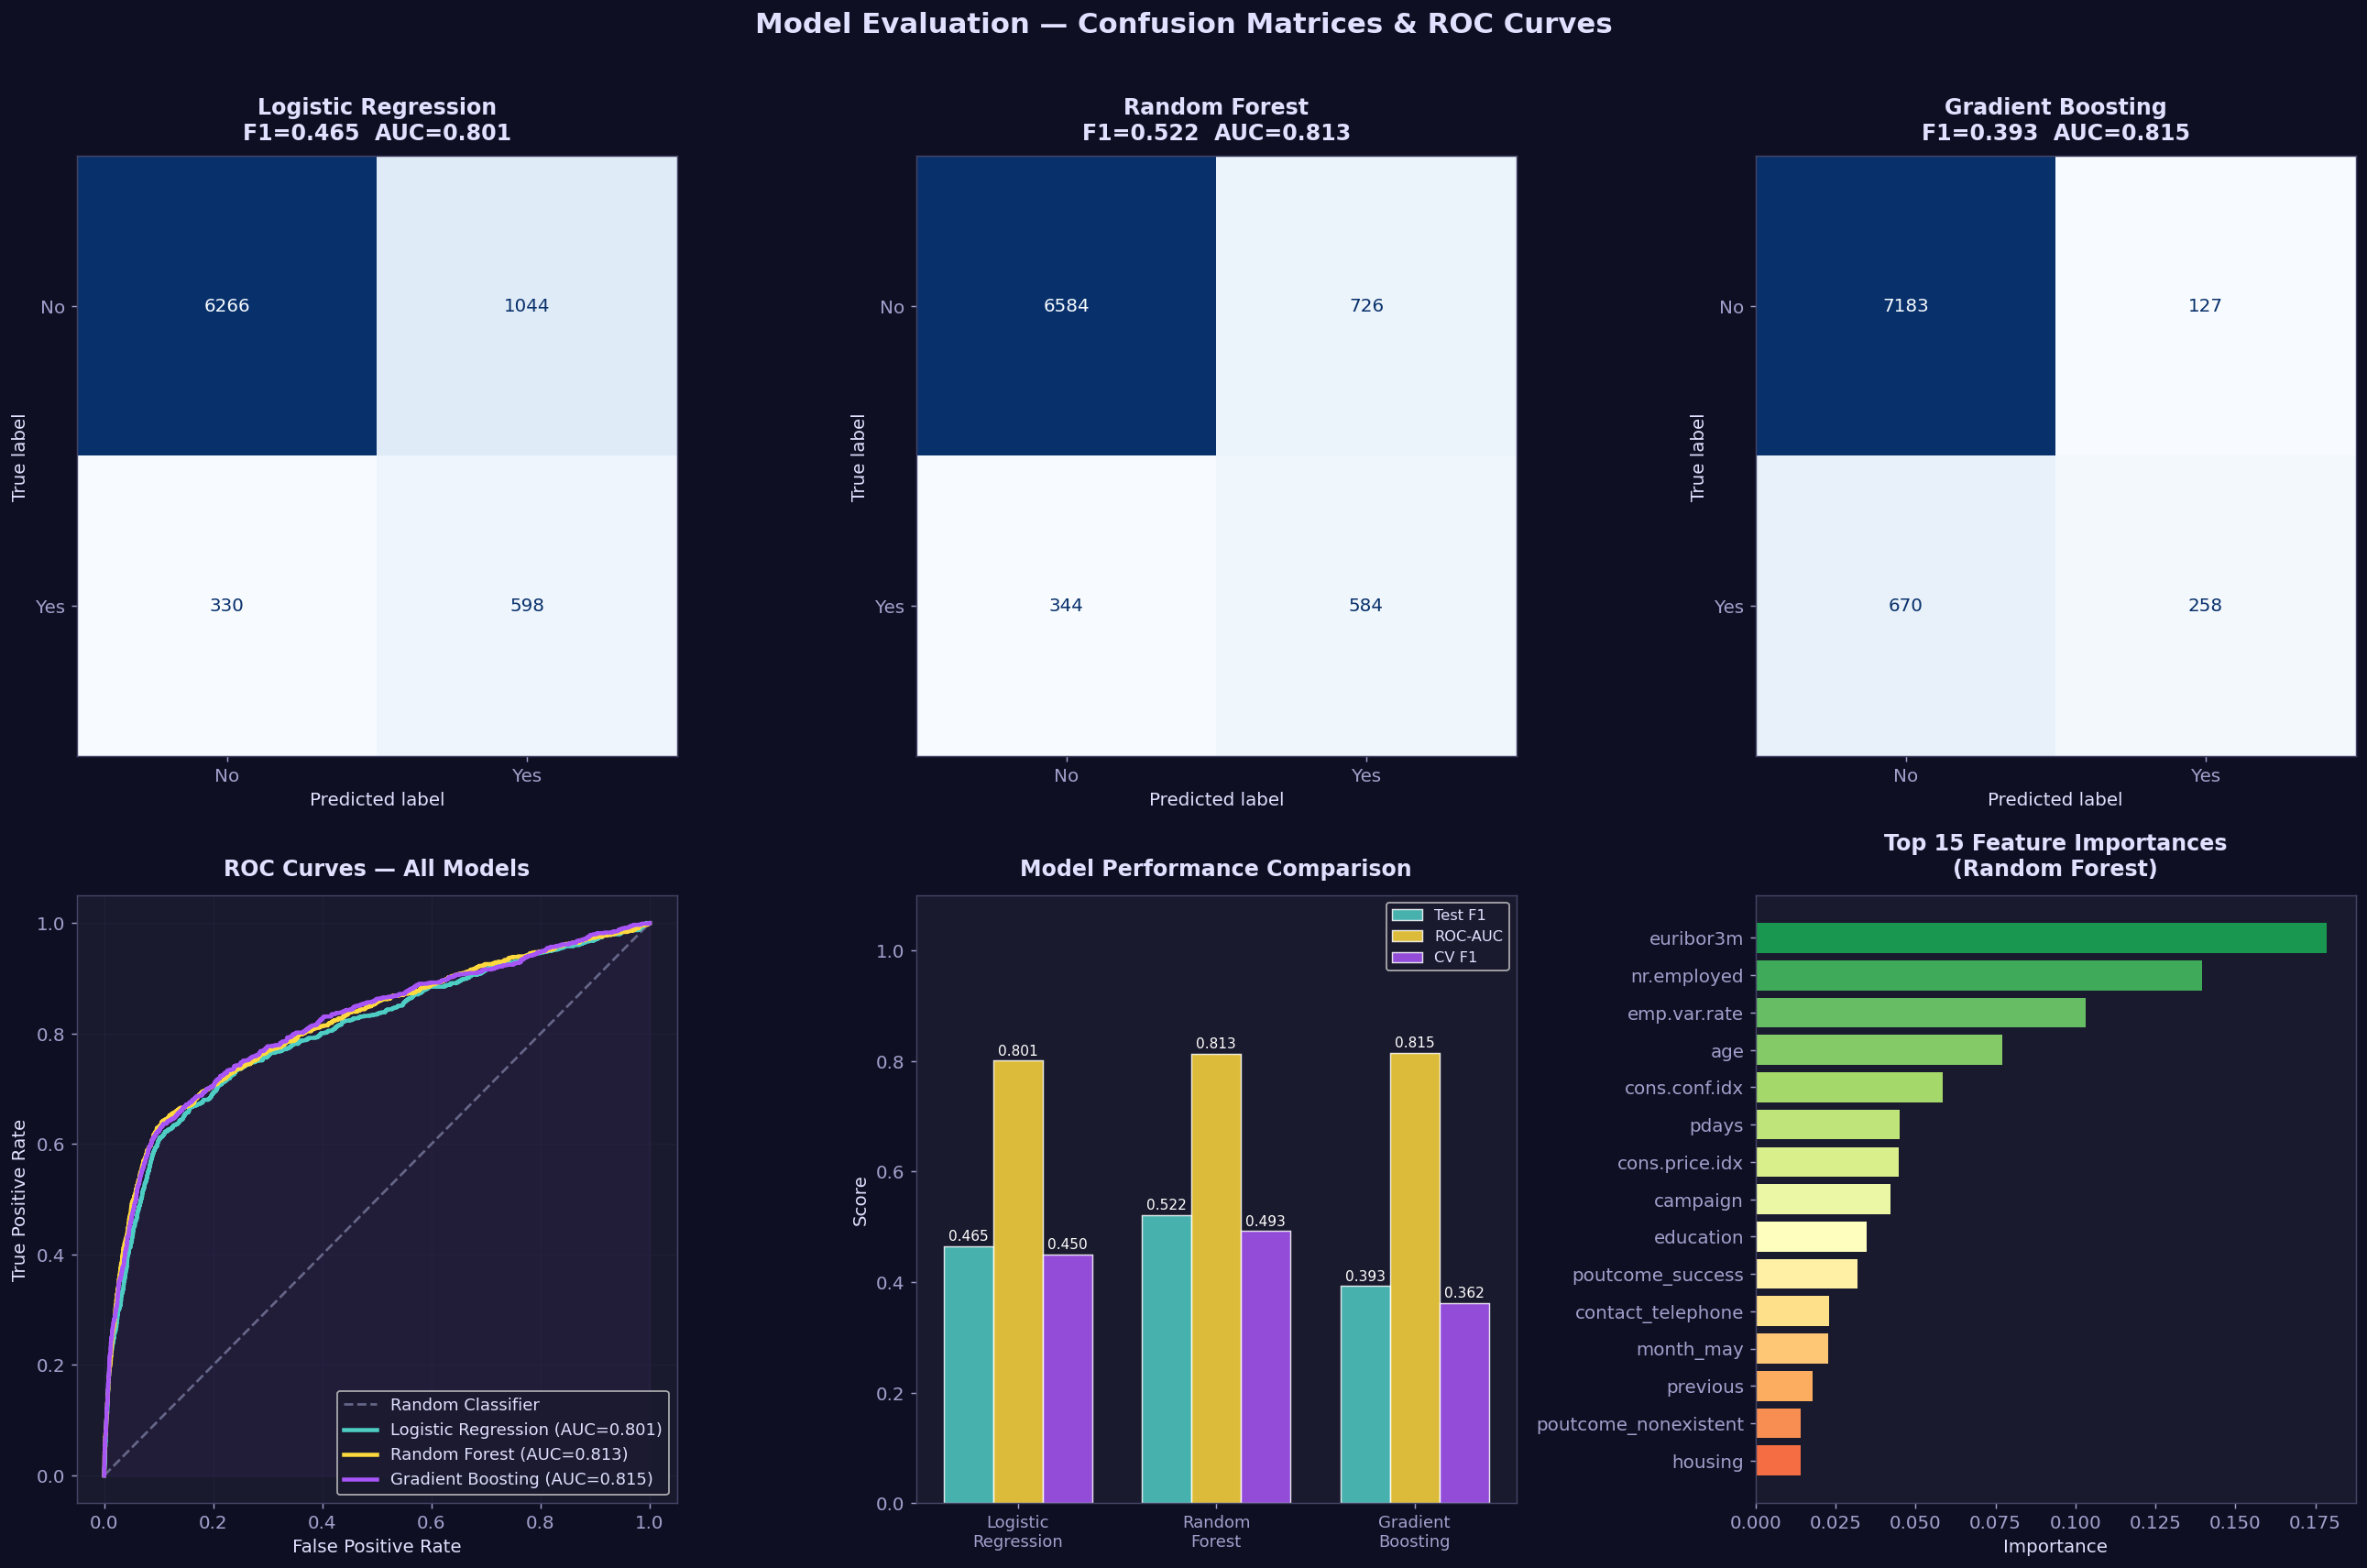

✅ Evaluation plots saved!


In [ ]:
# ── Figure 2: Confusion Matrices + ROC Curves ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
fig.suptitle('Model Evaluation — Confusion Matrices & ROC Curves',
             fontsize=17, fontweight='bold', color='#e0e0ff', y=1.01)

model_names = list(results.keys())
colors_roc  = ['#4ecdc4', '#ffd93d', '#a855f7']

# Confusion matrices (top row)
for i, name in enumerate(model_names):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No','Yes'])
    disp.plot(ax=axes[0,i], colorbar=False, cmap='Blues')
    axes[0,i].set_title(f'{name}\nF1={results[name]["f1"]:.3f}  AUC={results[name]["roc_auc"]:.3f}',
                        fontweight='bold', pad=10)
    axes[0,i].set_facecolor('#1a1a2e')

# ROC Curves (bottom row — all on one subplot)
ax_roc = axes[1,0]
ax_roc.plot([0,1],[0,1],'--', color='#666688', lw=1.5, label='Random Classifier')
for i, name in enumerate(model_names):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    ax_roc.plot(fpr, tpr, color=colors_roc[i], lw=2.5,
                label=f'{name} (AUC={results[name]["roc_auc"]:.3f})')
ax_roc.fill_between(fpr, tpr, alpha=0.05, color=colors_roc[-1])
ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves — All Models', fontweight='bold', pad=12)
ax_roc.legend(fontsize=10, loc='lower right')
ax_roc.grid(True, alpha=0.3)

# Model comparison bar chart
ax_bar = axes[1,1]
metrics = ['f1', 'roc_auc', 'cv_f1']
x = np.arange(len(model_names))
width = 0.25
metric_labels = ['Test F1', 'ROC-AUC', 'CV F1']
for j, (m, ml) in enumerate(zip(metrics, metric_labels)):
    vals = [results[n][m] for n in model_names]
    bars = ax_bar.bar(x + j*width, vals, width, label=ml,
                      color=colors_roc[j], edgecolor='white', linewidth=0.8, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax_bar.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8.5, color='white')
ax_bar.set_xticks(x + width)
ax_bar.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=10)
ax_bar.set_ylim(0, 1.1)
ax_bar.set_title('Model Performance Comparison', fontweight='bold', pad=12)
ax_bar.legend(fontsize=9)
ax_bar.set_ylabel('Score')

# Feature importance (Random Forest)
ax_fi = axes[1,2]
rf_model = trained_models['Random Forest'][0]
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top15 = importances.nlargest(15).sort_values()
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, 15))
ax_fi.barh(top15.index, top15.values, color=colors_fi, edgecolor='none')
ax_fi.set_title('Top 15 Feature Importances\n(Random Forest)', fontweight='bold', pad=12)
ax_fi.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('task1_evaluation.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Evaluation plots saved!')

## 🔎 Step 7: Model Explainability — SHAP

In [ ]:
# ── SHAP Explanations for Random Forest ──────────────────────────────────────
print('🔍 Computing SHAP values (TreeExplainer on Random Forest)...')

rf_model_shap = trained_models['Random Forest'][0]
X_test_shap   = trained_models['Random Forest'][2]  # X_test (unscaled)

# Use a sample for speed
X_shap_sample = X_test_shap.sample(500, random_state=42)

explainer   = shap.TreeExplainer(rf_model_shap)
shap_values = explainer.shap_values(X_shap_sample)

# For binary classification, take class=1 SHAP values
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f'✅ SHAP values computed for {X_shap_sample.shape[0]} samples')
print(f'   SHAP array shape: {sv.shape}')

🔍 Computing SHAP values (TreeExplainer on Random Forest)...
✅ SHAP values computed for 500 samples
   SHAP array shape: (500, 41, 2)


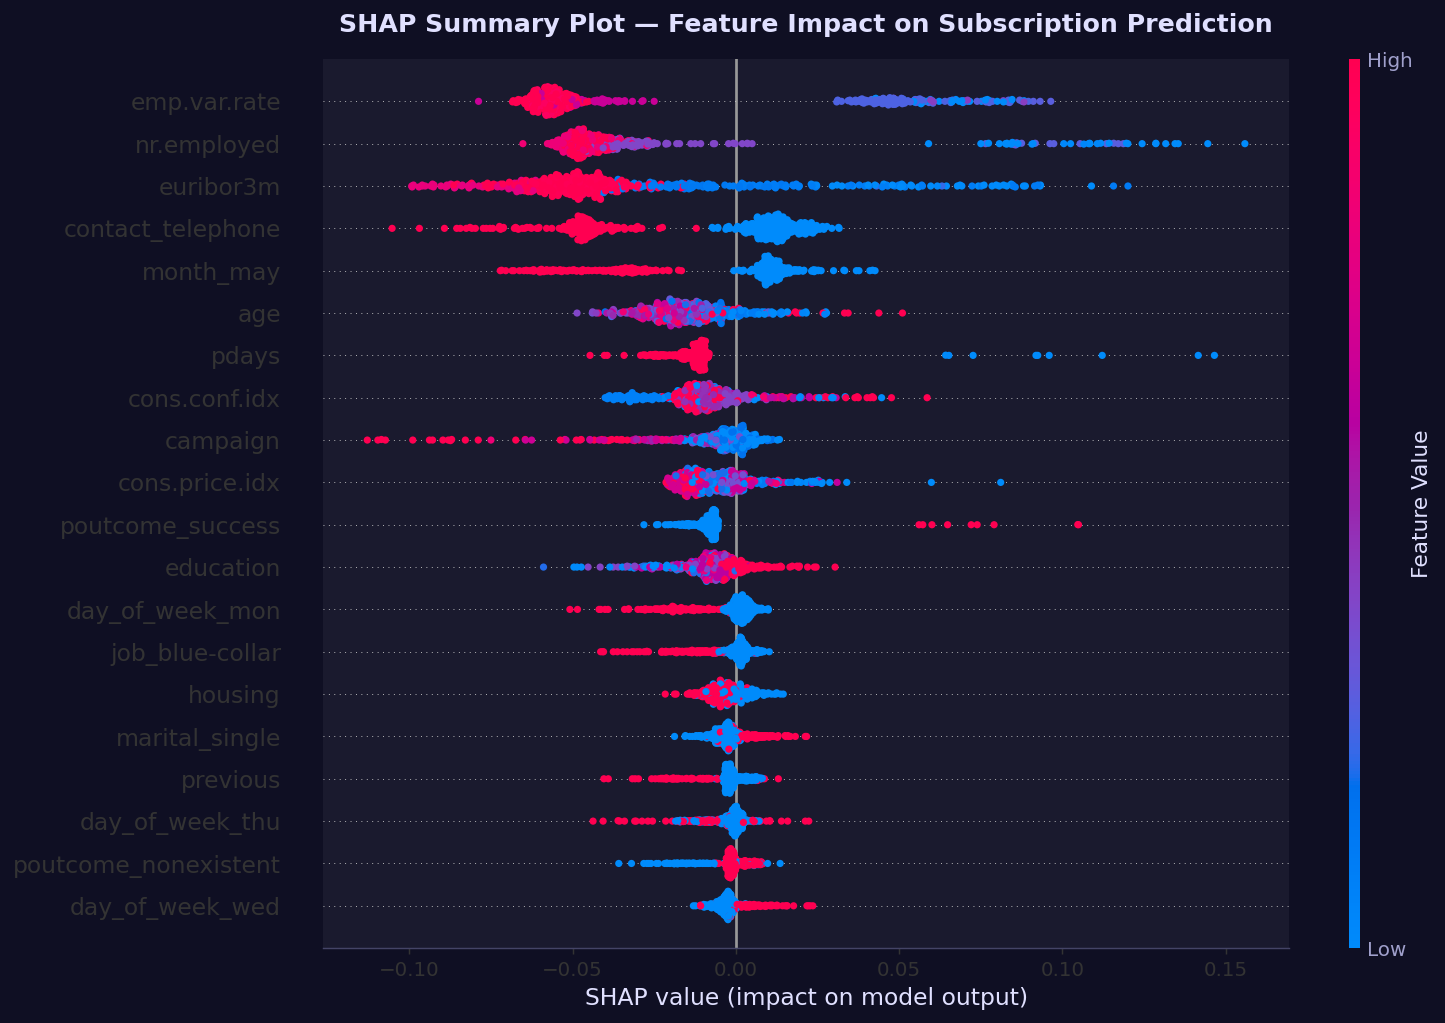

✅ SHAP summary plot saved!


In [ ]:
# ── SHAP Summary Plot (Beeswarm) ──────────────────────────────────────────────
plt.figure(figsize=(12, 8))
plt.title('SHAP Summary Plot — Feature Impact on Subscription Prediction',
          fontsize=14, fontweight='bold', pad=15)
shap.summary_plot(sv_class_1, X_shap_sample, show=False, plot_size=None,
                  color_bar_label='Feature Value')
plt.tight_layout()
plt.savefig('task1_shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ SHAP summary plot saved!')

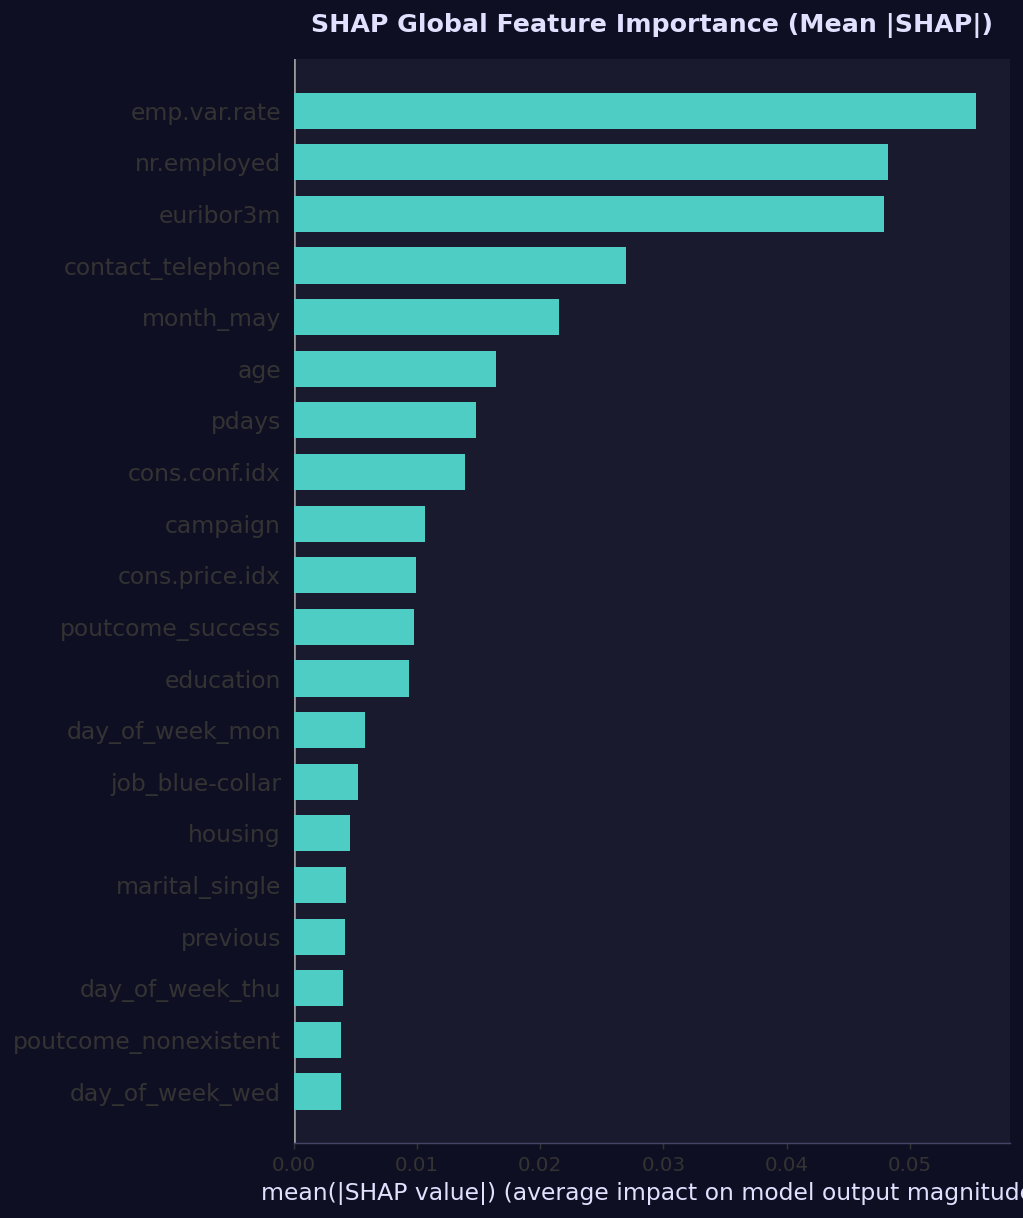

In [ ]:
# ── SHAP Bar Plot — Global Feature Importance ─────────────────────────────────
plt.figure(figsize=(10, 7))
plt.title('SHAP Global Feature Importance (Mean |SHAP|)',
          fontsize=14, fontweight='bold', pad=15)
shap.summary_plot(sv_class_1, X_shap_sample, plot_type='bar', show=False,
                  color='#4ecdc4')
plt.tight_layout()
plt.savefig('task1_shap_bar.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# ── SHAP Force Plots ─ 5 Individual Predictions ─────────────────────────
print('🔍 Explaining 5 individual predictions with SHAP force plots...')

# Get 3 'yes' predictions and 2 'no' predictions
pred_probs = rf_model_shap.predict_proba(X_shap_sample)[:,1]
yes_idx = np.where(pred_probs > 0.6)[0][:3]
no_idx  = np.where(pred_probs < 0.2)[0][:2]
indices = list(yes_idx) + list(no_idx)

# Correctly get the base value for the positive class (class 1)
# explainer.expected_value can be a list or a numpy array of two values for binary classification.
# We need the expected value for class 1.
base_val = explainer.expected_value[1]

# Correctly get SHAP values for the positive class (class 1)
# sv from the kernel state is a 3D array (num_samples, num_features, num_classes).
# We need sv_class_1 to be (num_samples, num_features).
sv_class_1 = sv[:, :, 1]

for rank, idx in enumerate(indices[:5], 1):
    prob = pred_probs[idx]
    decision = 'SUBSCRIBE ✅' if prob > 0.5 else 'NOT SUBSCRIBE ❌'
    print(f'\n--- Prediction #{rank}: {decision} (Probability: {prob:.3f}) ---')
    print(f'Base value (expected): {base_val:.4f}')
    print(f'Predicted probability: {prob:.4f}')

    # Top 5 features driving this prediction
    # Use the corrected sv_class_1
    feat_imp = pd.Series(sv_class_1[idx], index=X_shap_sample.columns)
    top5     = feat_imp.abs().nlargest(5)
    print('\n  Top 5 influential features:')
    for feat in top5.index:
        direction = '⬆️ +' if feat_imp[feat] > 0 else '⬇️ -'
        print(f'    {direction}{abs(feat_imp[feat]):.4f}  [{feat}] '
              f'= {X_shap_sample.iloc[idx][feat]:.3f}')


🔍 Explaining 5 individual predictions with SHAP force plots...

--- Prediction #1: SUBSCRIBE ✅ (Probability: 0.803) ---
Base value (expected): 0.5000
Predicted probability: 0.8027

  Top 5 influential features:
    ⬆️ +0.1107  [nr.employed] = 5023.500
    ⬆️ +0.0843  [euribor3m] = 0.700
    ⬆️ +0.0800  [emp.var.rate] = -3.000
    ⬆️ +0.0476  [cons.conf.idx] = -33.000
    ⬇️ -0.0333  [job_blue-collar] = 1.000

--- Prediction #2: SUBSCRIBE ✅ (Probability: 0.821) ---
Base value (expected): 0.5000
Predicted probability: 0.8210

  Top 5 influential features:
    ⬆️ +0.1345  [nr.employed] = 4991.600
    ⬆️ +0.0911  [emp.var.rate] = -1.700
    ⬆️ +0.0880  [euribor3m] = 0.702
    ⬆️ +0.0278  [contact_telephone] = 0.000
    ⬇️ -0.0178  [age] = 37.000

--- Prediction #3: SUBSCRIBE ✅ (Probability: 0.812) ---
Base value (expected): 0.5000
Predicted probability: 0.8118

  Top 5 influential features:
    ⬆️ +0.1157  [nr.employed] = 5076.200
    ⬆️ +0.0846  [emp.var.rate] = -2.900
    ⬆️ +0.0723  [eu

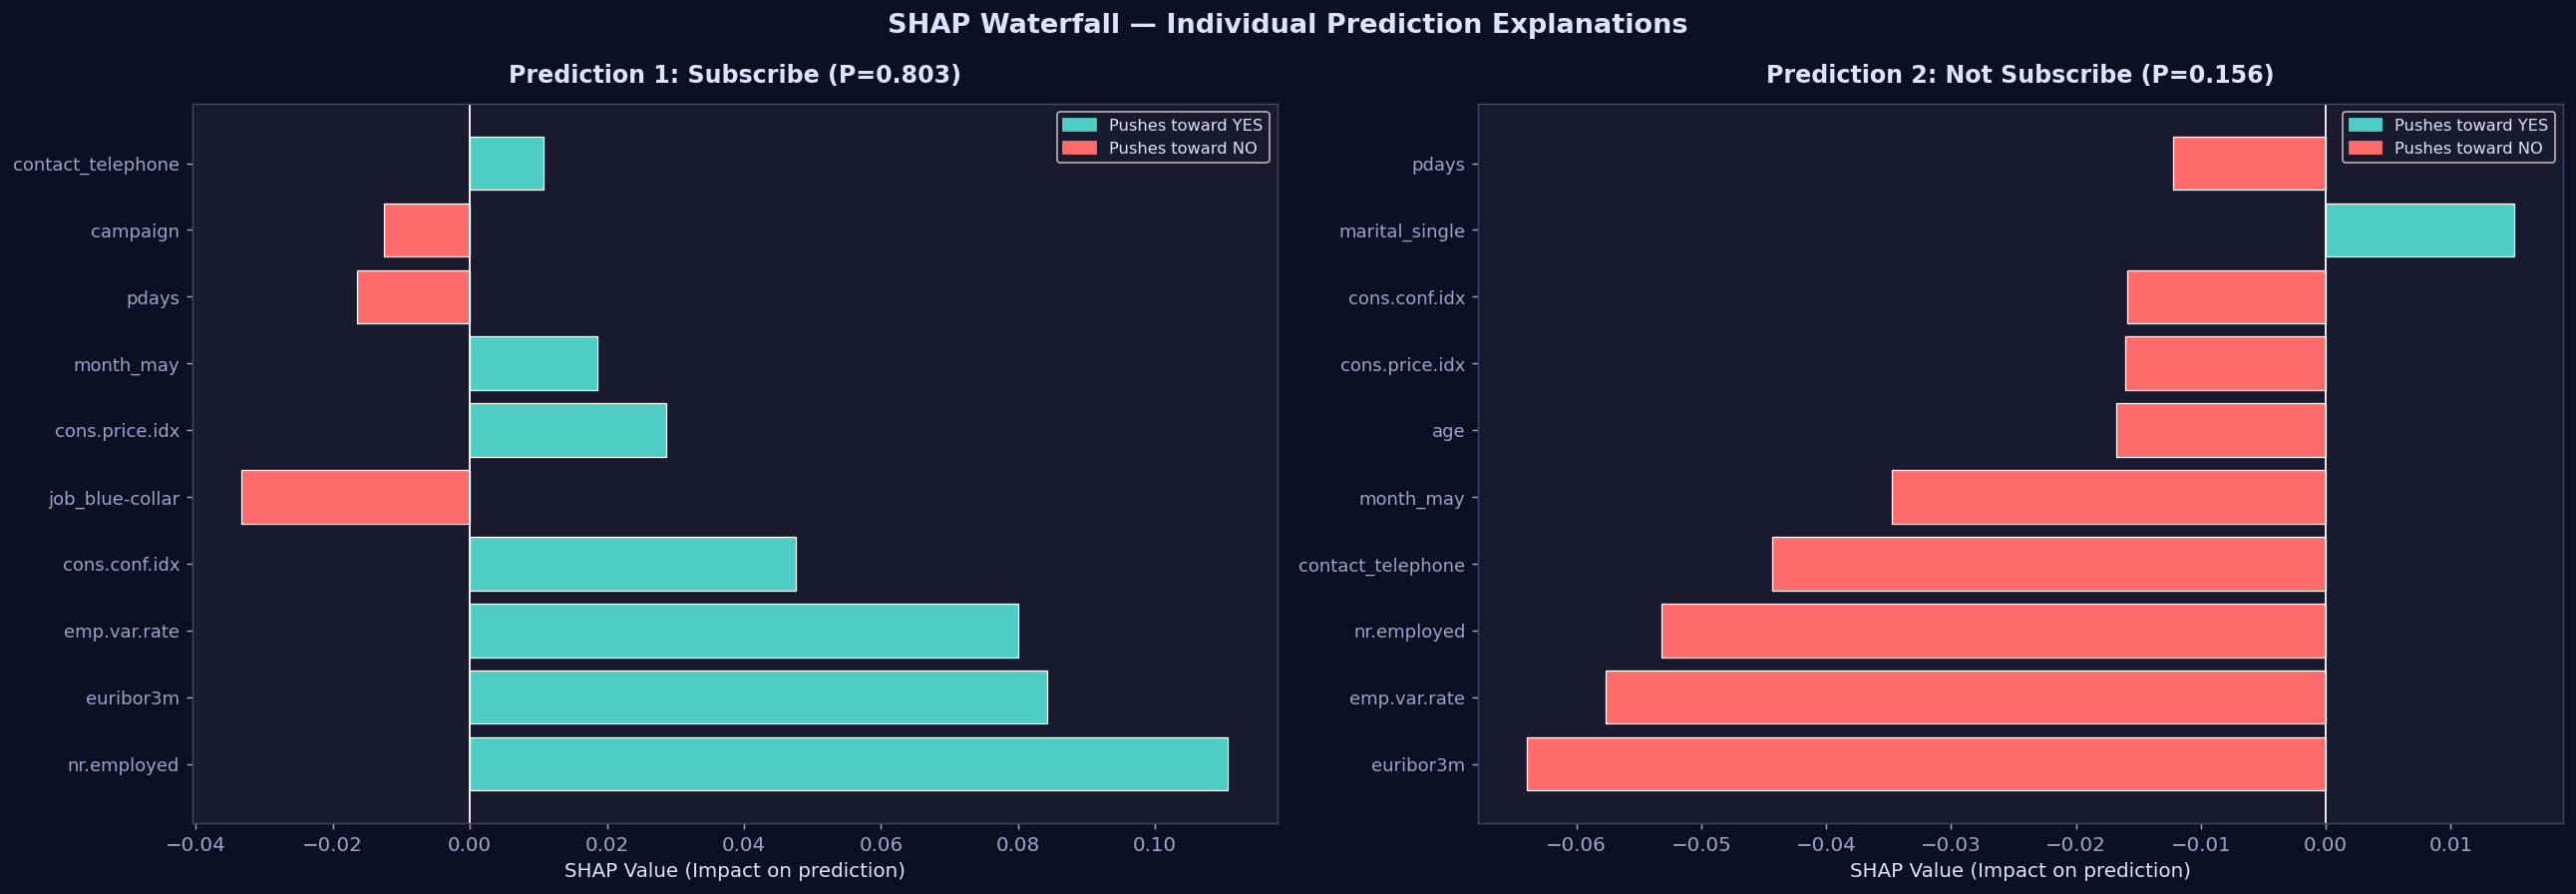

✅ SHAP waterfall plots saved!


In [ ]:
# ── SHAP Waterfall — Individual Explanation Visualization ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('SHAP Waterfall — Individual Prediction Explanations',
             fontsize=15, fontweight='bold', color='#e0e0ff')

for plot_i, (idx, ax) in enumerate(zip([yes_idx[0], no_idx[0]], axes)):
    feat_imp = pd.Series(sv_class_1[idx], index=X_shap_sample.columns)
    top_n = feat_imp.abs().nlargest(10)
    top_vals = feat_imp[top_n.index]

    colors_wf = ['#4ecdc4' if v > 0 else '#ff6b6b' for v in top_vals]
    y_pos = range(len(top_vals))
    ax.barh(y_pos, top_vals.values, color=colors_wf, edgecolor='white', linewidth=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_vals.index, fontsize=10)
    ax.axvline(0, color='white', linewidth=1)
    ax.set_xlabel('SHAP Value (Impact on prediction)', fontsize=11)
    prob = pred_probs[idx]
    decision = 'Subscribe' if prob > 0.5 else 'Not Subscribe'
    ax.set_title(f'Prediction {plot_i+1}: {decision} (P={prob:.3f})',
                 fontweight='bold', pad=12)

    pos_patch = mpatches.Patch(color='#4ecdc4', label='Pushes toward YES')
    neg_patch = mpatches.Patch(color='#ff6b6b', label='Pushes toward NO')
    ax.legend(handles=[pos_patch, neg_patch], fontsize=9)

plt.tight_layout()
plt.savefig('task1_shap_waterfall.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ SHAP waterfall plots saved!')

## 🟡 Step 8: LIME — Local Interpretable Model-agnostic Explanations

🟡 Setting up LIME explainer...


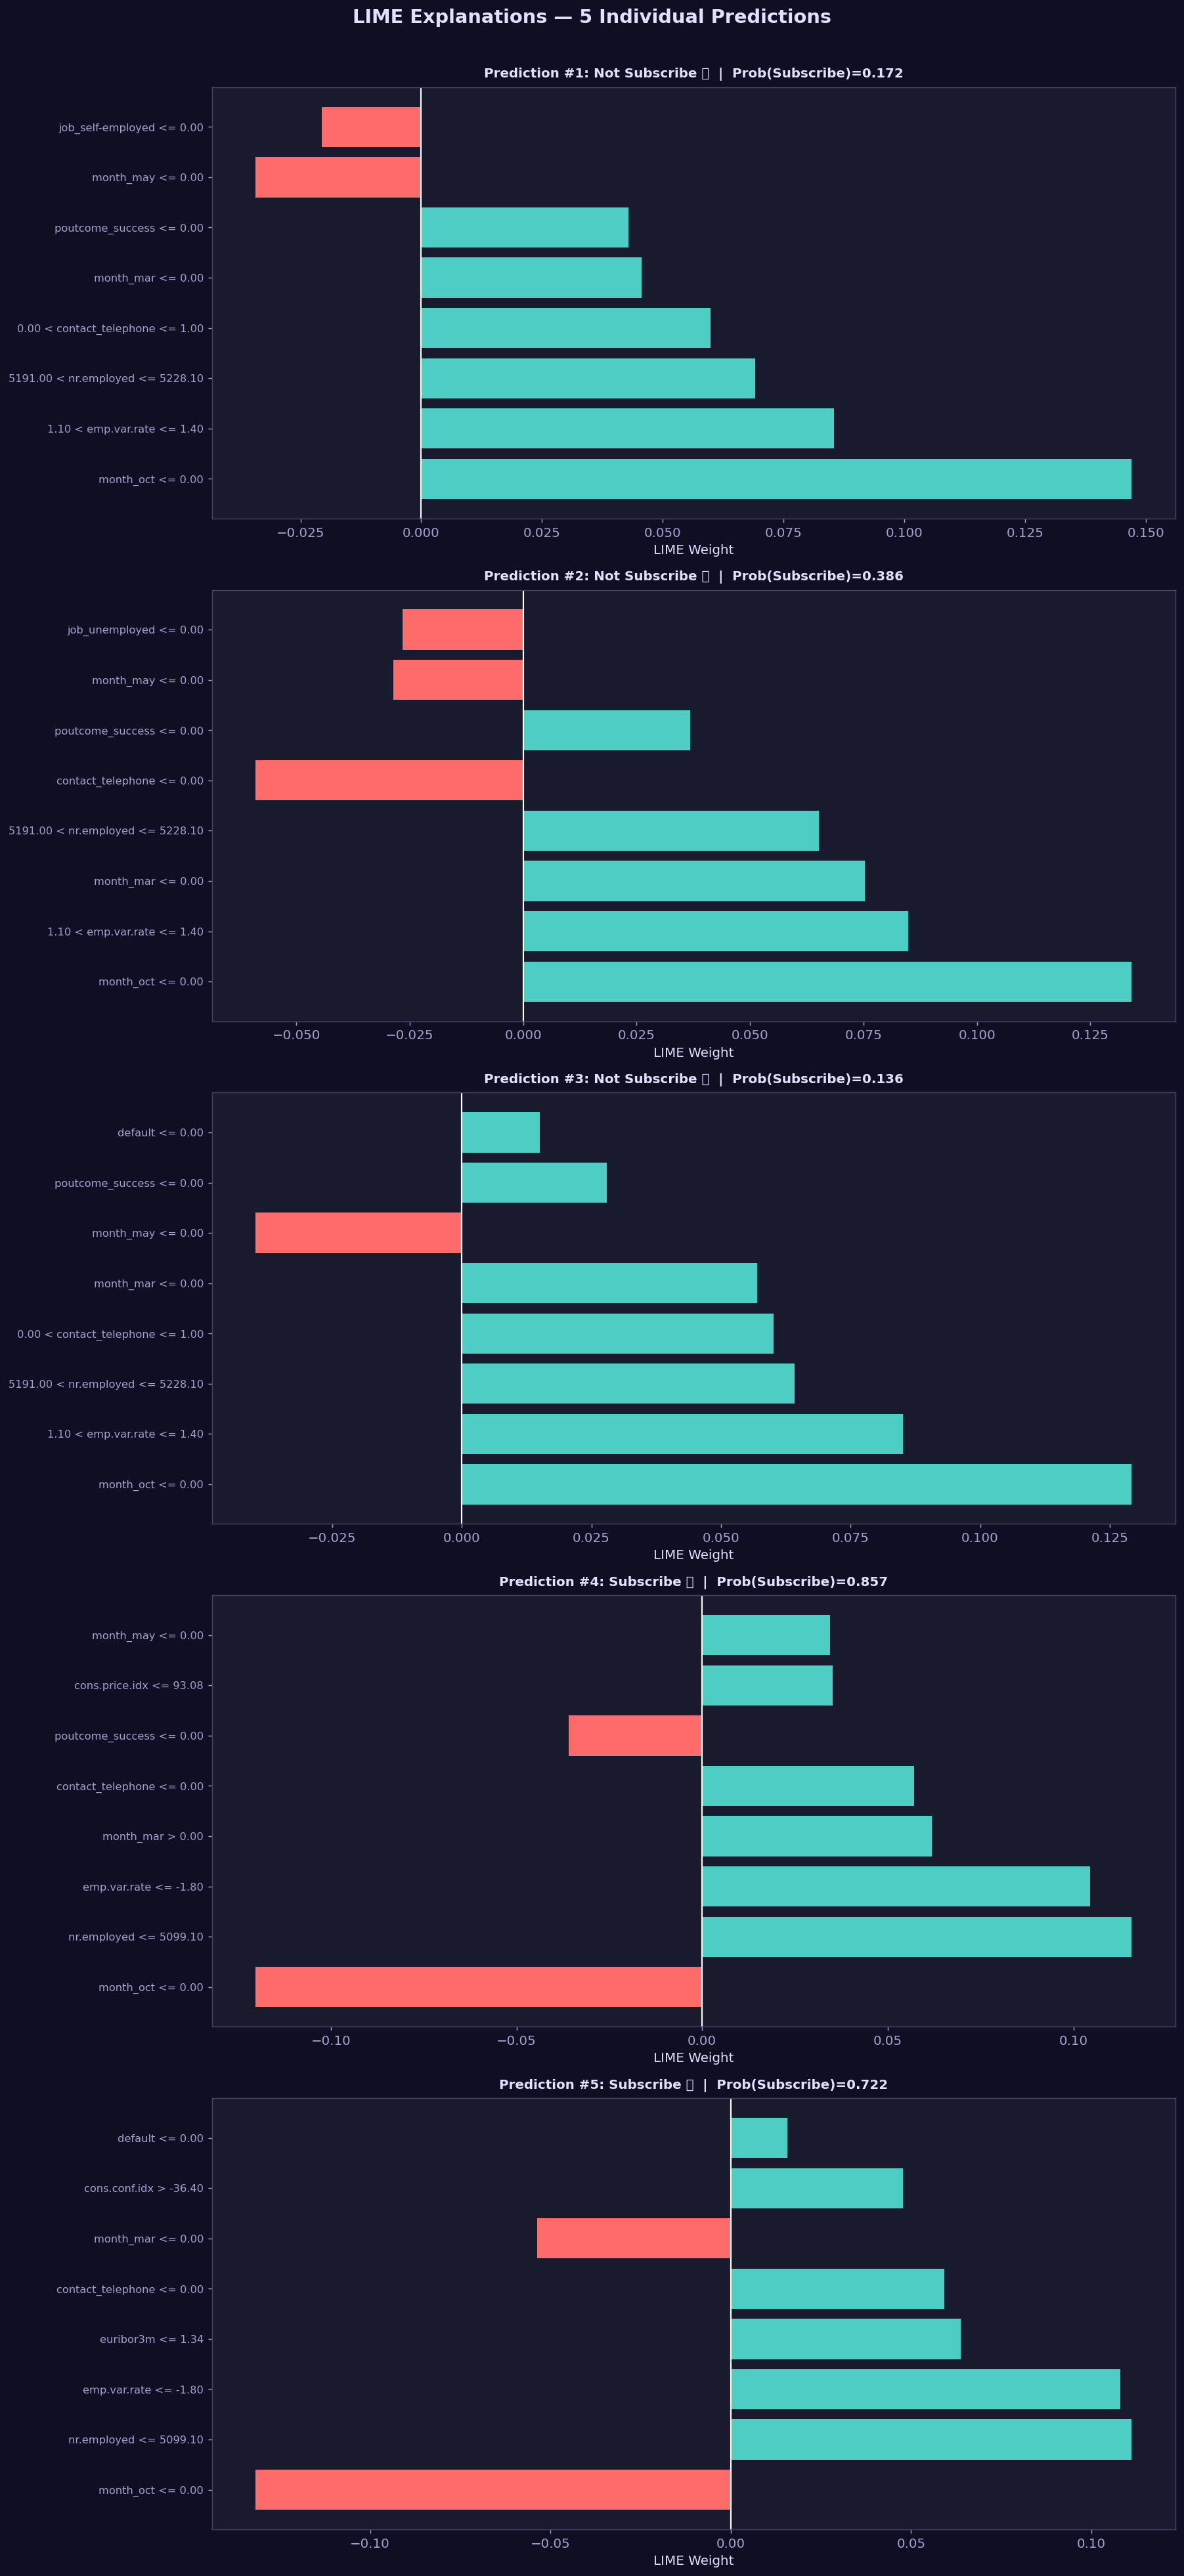

✅ LIME explanations saved!


In [ ]:
# ── LIME Explainer Setup ──────────────────────────────────────────────────────
print('🟡 Setting up LIME explainer...')

rf_model_lime = trained_models['Random Forest'][0]
X_test_lime   = trained_models['Random Forest'][2]

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train.values,
    feature_names  = X_train.columns.tolist(),
    class_names    = ['No Subscribe', 'Subscribe'],
    mode           = 'classification',
    random_state   = 42
)

# Explain 5 predictions with LIME
fig, axes = plt.subplots(5, 1, figsize=(14, 30))
fig.suptitle('LIME Explanations — 5 Individual Predictions',
             fontsize=16, fontweight='bold', color='#e0e0ff', y=1.005)

lime_indices = list(yes_idx[:3]) + list(no_idx[:2])

for rank, (idx, ax) in enumerate(zip(lime_indices, axes), 1):
    sample = X_test_lime.iloc[idx].values
    exp = lime_explainer.explain_instance(
        sample,
        rf_model_lime.predict_proba,
        num_features=8,
        top_labels=1
    )
    label = exp.available_labels()[0]
    lime_list = exp.as_list(label=label)
    prob = rf_model_lime.predict_proba([sample])[0][1]
    decision = 'Subscribe ✅' if prob > 0.5 else 'Not Subscribe ❌'

    feats  = [x[0][:40] for x in lime_list]
    weights= [x[1] for x in lime_list]
    colors_l = ['#4ecdc4' if w > 0 else '#ff6b6b' for w in weights]

    ax.barh(feats, weights, color=colors_l, edgecolor='none')
    ax.axvline(0, color='white', linewidth=1.2)
    ax.set_title(f'Prediction #{rank}: {decision}  |  Prob(Subscribe)={prob:.3f}',
                 fontweight='bold', fontsize=11, pad=8)
    ax.set_xlabel('LIME Weight')
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('task1_lime_explanations.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ LIME explanations saved!')

## 📋 Step 9: Final Summary & Business Insights

In [ ]:
# ── Model Performance Summary Table ──────────────────────────────────────────
summary_df = pd.DataFrame({
    'Model': list(results.keys()),
    'F1-Score': [results[n]['f1'] for n in results],
    'ROC-AUC':  [results[n]['roc_auc'] for n in results],
    'CV F1 (5-fold)': [results[n]['cv_f1'] for n in results]
}).set_index('Model').round(4)

best_model = summary_df['ROC-AUC'].idxmax()

print('='*60)
print('  FINAL MODEL PERFORMANCE SUMMARY')
print('='*60)
print(summary_df.to_string())
print(f'\n🏆 Best Model: {best_model}')
print(f'   ROC-AUC : {summary_df.loc[best_model, "ROC-AUC"]:.4f}')
print(f'   F1-Score: {summary_df.loc[best_model, "F1-Score"]:.4f}')

print('\n' + '='*60)
print('  KEY BUSINESS INSIGHTS (from SHAP & EDA)')
print('='*60)
insights = [
    '1. nr.employed (# employed) is the strongest macro predictor — lower employment signals economic pressure, nudging customers toward savings (term deposits).',
    '2. euribor3m (interest rate): Lower Euribor rates correlate with higher subscription, as term deposits become relatively attractive.',
    '3. pdays (days since last contact): Recent contacts dramatically improve conversion — call recency matters.',
    '4. previous (# previous contacts): Customers who were contacted before and responded positively (poutcome=success) convert at much higher rates.',
    '5. age: Older customers (55+) and younger customers (25-30) subscribe at higher rates.',
    '6. Job type: Retired and student customers have the highest subscription rates.',
    '7. month: May is the most common call month but not the highest conversion — March, Sep, Oct, Dec show better rates.'
]
for i in insights:
    print(f'\n  {i}')

  FINAL MODEL PERFORMANCE SUMMARY
                     F1-Score  ROC-AUC  CV F1 (5-fold)
Model                                                 
Logistic Regression    0.4654   0.8012          0.4502
Random Forest          0.5219   0.8134          0.4928
Gradient Boosting      0.3930   0.8149          0.3623

🏆 Best Model: Gradient Boosting
   ROC-AUC : 0.8149
   F1-Score: 0.3930

  KEY BUSINESS INSIGHTS (from SHAP & EDA)

  1. nr.employed (# employed) is the strongest macro predictor — lower employment signals economic pressure, nudging customers toward savings (term deposits).

  2. euribor3m (interest rate): Lower Euribor rates correlate with higher subscription, as term deposits become relatively attractive.

  3. pdays (days since last contact): Recent contacts dramatically improve conversion — call recency matters.

  4. previous (# previous contacts): Customers who were contacted before and responded positively (poutcome=success) convert at much higher rates.

  5. age: Older cus